# **ASSIGNMENT**

## **Time series forecasting model using Long Short-Term Memory (LSTM) neural networks in Airpassenger dataset**

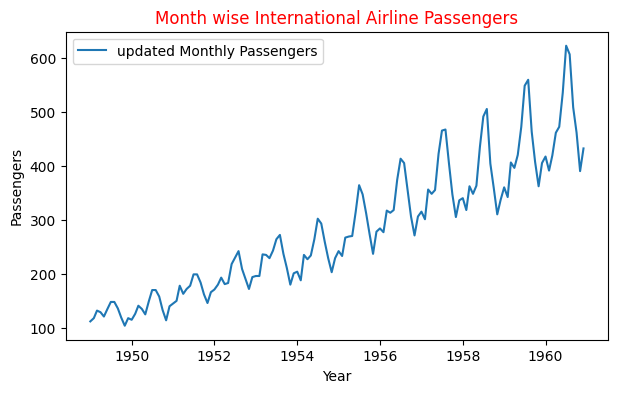

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0573 - val_loss: 0.0230
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0116 - val_loss: 0.0239
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - val_loss: 0.0302
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 0.0219
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0091 - val_loss: 0.0221
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0079 - val_loss: 0.0217
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0072 - val_loss: 0.0223
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0083 - val_loss: 0.0221
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074 - val_loss: 0.0219
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0073 - val_loss: 0.0214
Epoch 11/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0083 - val_loss: 0.0214
Epoch 12/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Train RMSE: 26.26
Test RMSE: 42.61


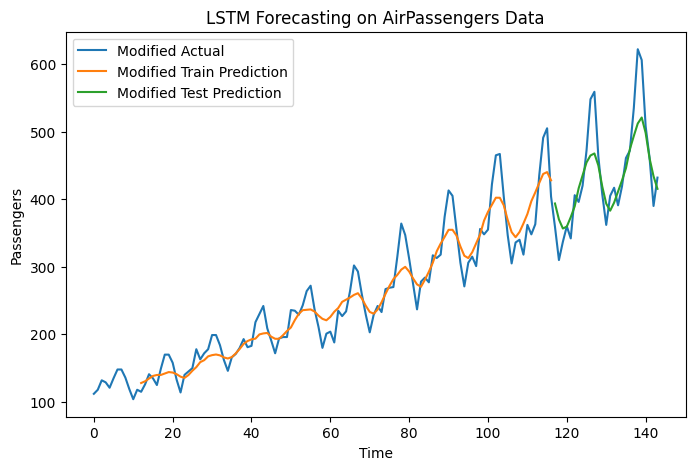

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import math


df = pd.read_csv('AirPassengers.csv')
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)


plt.figure(figsize=(7, 4))
plt.plot(df, label='updated Monthly Passengers')
plt.title("Month wise International Airline Passengers",color='red')
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df)


def create_dataset(dataset, time_step=12):
    X, Y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step, 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 12
X, y = create_dataset(data_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)


train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


model = Sequential()
model.add(LSTM(units=50, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=150, batch_size=8, verbose=1, callbacks=[early_stop])


train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


train_rmse = math.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_inv, test_predict))
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")


train_plot = np.empty_like(data_scaled)
train_plot[:, :] = np.nan
train_plot[time_step:len(train_predict)+time_step, 0] = train_predict[:, 0]

test_plot = np.empty_like(data_scaled)
test_plot[:, :] = np.nan
test_plot[len(train_predict)+(time_step):, 0] = test_predict[:, 0]

plt.figure(figsize=(8, 5))
plt.plot(scaler.inverse_transform(data_scaled), label='Modified Actual')
plt.plot(train_plot, label='Modified Train Prediction')
plt.plot(test_plot, label='Modified Test Prediction')
plt.title('LSTM Forecasting on AirPassengers Data')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.show()

Model Evaluation

In [3]:
from sklearn.metrics import r2_score


In [4]:
train_r2 = r2_score(y_train_inv, train_predict)
test_r2  = r2_score(y_test_inv,  test_predict)
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")


Train R²: 0.9195
Test  R²: 0.8266


Forecast future passengers

In [5]:
def forecast_future(model, data_scaled, scaler, time_step=12, n_future=12):
    """Returns an array of length n_future with forecasted (inverse-scaled) passenger counts."""

    last_seq = data_scaled[-time_step:].reshape(1, time_step, 1)
    preds_scaled = []
    for _ in range(n_future):

        next_scaled = model.predict(last_seq)[0,0]
        preds_scaled.append(next_scaled)

        last_seq = np.concatenate(
            [last_seq[:,1:,:], [[ [next_scaled] ]]], axis=1
        )

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1))
    return preds.flatten()


n_future = 12
future_preds = forecast_future(model, data_scaled, scaler, time_step, n_future)


for i, p in enumerate(future_preds, 1):
    print(f"Month +{i}: {p:.0f} passengers")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Month +1: 406 passengers
Month +2: 415 passengers
Month +3: 450 passengers
Month +4: 496 passengers
Month +5: 544 passengers
Month +6: 594 passengers
Month +7: 620 passengers
Month +8: 594 passengers
Month +9: 533 passengers
Month +10: 476 passengers
Month +11: 429 passengers
Month +12: 412 passengers


# Historical + forecast Plot

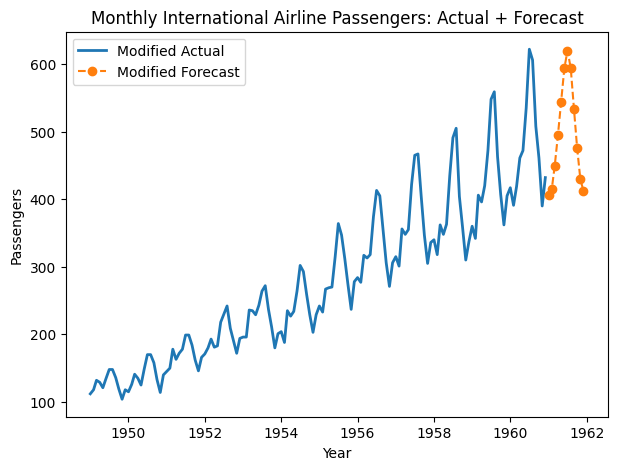

In [7]:

last_date = df.index[-1]
future_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(),
                             periods=n_future, freq='MS')

plt.figure(figsize=(7, 5))

plt.plot(df.index, df['Passengers'], label='Modified Actual', linewidth=2)

plt.plot(future_index, future_preds, label='Modified Forecast', linestyle='--', marker='o')
plt.title('Monthly International Airline Passengers: Actual + Forecast')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()